In [5]:
import pandas as pd

def load_stooq(symbol: str) -> pd.DataFrame:
    """
    Load daily data from Stooq.
    Returns a DataFrame indexed by Date with OHLCV columns (if available).
    """
    url = f"https://stooq.com/q/d/l/?s={symbol}&i=d"
    df = pd.read_csv(url)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    return df

# 1) Load data
gold = load_stooq("xauusd")      # Gold spot in USD
usdcny = load_stooq("usdcny")    # USD/CNY FX rate

gold.head(), usdcny.head()

(             Open   High    Low  Close
 Date                                  
 1793-03-01  19.39  19.39  19.39  19.39
 1793-06-01  19.39  19.39  19.39  19.39
 1793-09-01  19.39  19.39  19.39  19.39
 1793-12-01  19.39  19.39  19.39  19.39
 1794-03-01  19.39  19.39  19.39  19.39,
               Open    High     Low   Close
 Date                                      
 1984-01-09  3.5740  3.5740  3.5740  3.5740
 1984-01-16  3.6531  3.6531  3.6531  3.6531
 1984-01-23  3.6531  3.6531  3.6531  3.6531
 1984-01-30  3.6531  3.6531  3.6531  3.6531
 1984-02-06  3.6531  3.6531  3.6531  3.6531)

In [7]:
import pandas as pd

# 1) 取 Close，并限制到现代区间（你也可以改成 2010-01-01）
start = "2005-01-01"
gold_c = gold["Close"].loc[start:].rename("XAUUSD")
fx_c = usdcny["Close"].loc[start:].rename("USDCNY")

# 2) 合并对齐（只保留两者都有数据的日期）
df = pd.concat([gold_c, fx_c], axis=1).dropna()

# 3) 换算：人民币金价（“每盎司人民币”）
df["XAU_CNY_per_oz"] = df["XAUUSD"] * df["USDCNY"]

# 4) 看一下数据情况
print("Rows:", len(df))
print("Date range:", df.index.min().date(), "->", df.index.max().date())
df.head()

Rows: 5214
Date range: 2005-01-03 -> 2026-03-05


,XAUUSD,USDCNY,XAU_CNY_per_oz
Date,,,
2005-01-03,428.5,8.3168,3563.74880
2005-01-04,427.1,8.4437,3606.30427
2005-01-05,425.9,8.2280,3504.30520
2005-01-06,421.4,8.2226,3465.00364
2005-01-07,418.5,8.3488,3493.97280


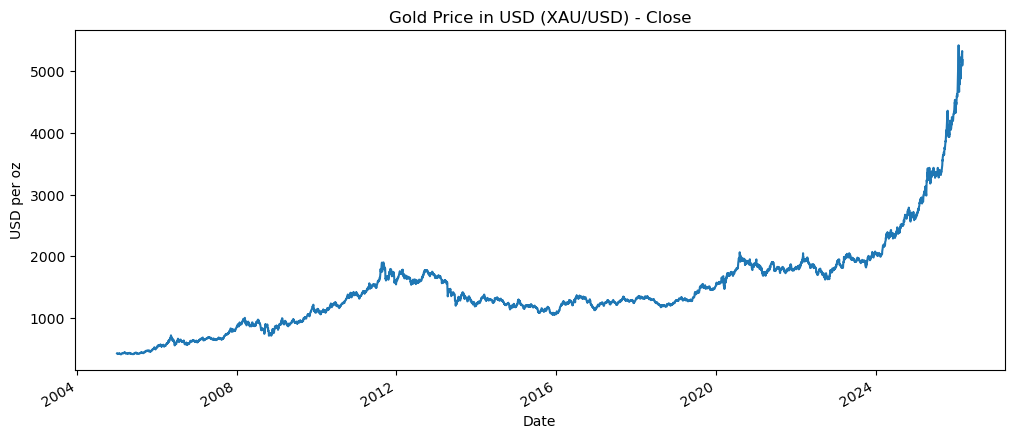

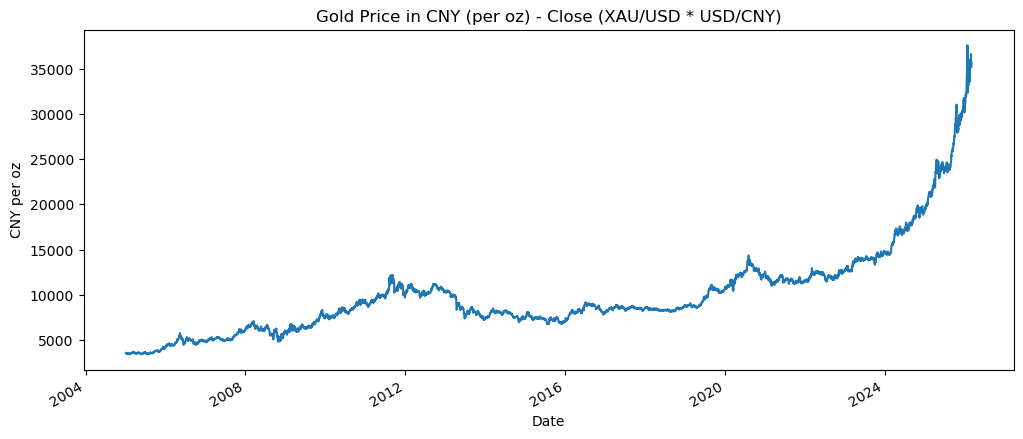

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))
df["XAUUSD"].plot(ax=ax)
ax.set_title("Gold Price in USD (XAU/USD) - Close")
ax.set_ylabel("USD per oz")
plt.show()

fig, ax = plt.subplots(figsize=(12,5))
df["XAU_CNY_per_oz"].plot(ax=ax)
ax.set_title("Gold Price in CNY (per oz) - Close (XAU/USD * USD/CNY)")
ax.set_ylabel("CNY per oz")
plt.show()

In [12]:
import numpy as np

# log returns（对乘法关系最友好）
ret = np.log(df[["XAUUSD", "USDCNY", "XAU_CNY_per_oz"]]).diff().dropna()
ret.columns = ["r_xauusd", "r_usdcny", "r_xau_cny"]

# 检查“分解是否成立”：r_cny ≈ r_xauusd + r_usdcny
ret["residual"] = ret["r_xau_cny"] - (ret["r_xauusd"] + ret["r_usdcny"])

print("Residual mean:", ret["residual"].mean())
print("Residual std :", ret["residual"].std())
ret.head()

Residual mean: 4.259439956359703e-20
Residual std : 8.087459722971374e-16


,r_xauusd,r_usdcny,r_xau_cny,residual
Date,,,,
2005-01-04,-0.003273,0.015143,0.011870,-8.881784e-16
2005-01-05,-0.002814,-0.025878,-0.028691,4.440892e-16
2005-01-06,-0.010622,-0.000657,-0.011279,1.332268e-15
2005-01-07,-0.006906,0.015231,0.008326,-1.776357e-15
2005-01-10,0.000239,-0.008806,-0.008567,4.440892e-16


In [14]:
# 相关系数矩阵
corr = ret[["r_xauusd", "r_usdcny", "r_xau_cny"]].corr()
print(corr)

# 年化波动率（假设 252 个交易日）
ann_vol = ret[["r_xauusd", "r_usdcny", "r_xau_cny"]].std() * np.sqrt(252)
print("\nAnnualized vol (approx):")
print(ann_vol)

           r_xauusd  r_usdcny  r_xau_cny
r_xauusd   1.000000 -0.099200   0.849916
r_usdcny  -0.099200  1.000000   0.440007
r_xau_cny  0.849916  0.440007   1.000000

Annualized vol (approx):
r_xauusd     0.177604
r_usdcny     0.104213
r_xau_cny    0.196803
dtype: float64


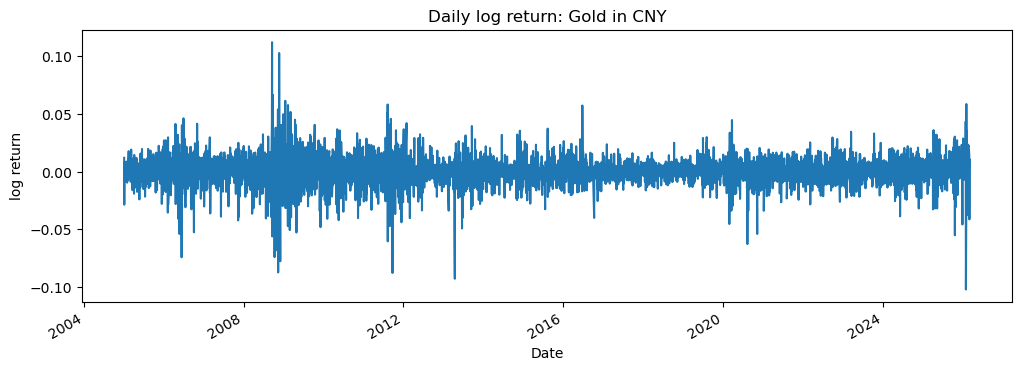

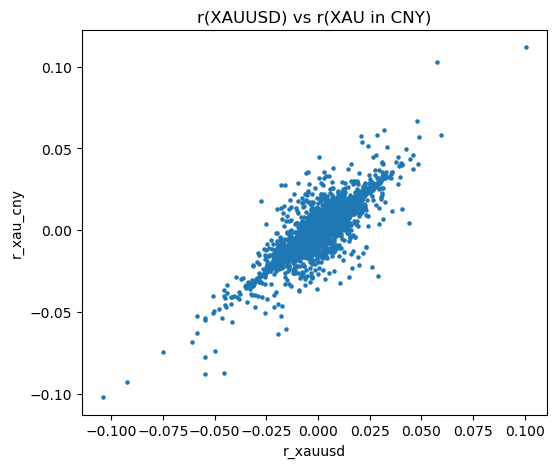

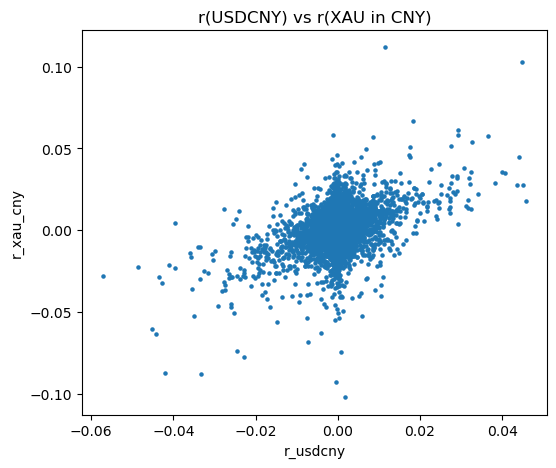

In [16]:
import matplotlib.pyplot as plt

# 1) 收益率时间序列（人民币金价）
ret["r_xau_cny"].plot(figsize=(12,4))
plt.title("Daily log return: Gold in CNY")
plt.ylabel("log return")
plt.show()

# 2) 相关性散点：美元金价收益 vs 人民币金价收益
plt.figure(figsize=(6,5))
plt.scatter(ret["r_xauusd"], ret["r_xau_cny"], s=5)
plt.title("r(XAUUSD) vs r(XAU in CNY)")
plt.xlabel("r_xauusd")
plt.ylabel("r_xau_cny")
plt.show()

# 3) 相关性散点：汇率收益 vs 人民币金价收益
plt.figure(figsize=(6,5))
plt.scatter(ret["r_usdcny"], ret["r_xau_cny"], s=5)
plt.title("r(USDCNY) vs r(XAU in CNY)")
plt.xlabel("r_usdcny")
plt.ylabel("r_xau_cny")
plt.show()

In [20]:
vx = ret["r_xauusd"].var()
vf = ret["r_usdcny"].var()
cov = ret["r_xauusd"].cov(ret["r_usdcny"])
vc = ret["r_xau_cny"].var()

share_x = vx / vc
share_f = vf / vc
share_cov = (2*cov) / vc

print("Variance shares (approx):")
print("Gold USD component:", share_x)
print("FX component      :", share_f)
print("2*Cov component   :", share_cov)
print("Sum               :", share_x + share_f + share_cov)

Variance shares (approx):
Gold USD component: 0.8144085198838422
FX component      : 0.2804015677796475
2*Cov component   : -0.09481008766349068
Sum               : 0.999999999999999


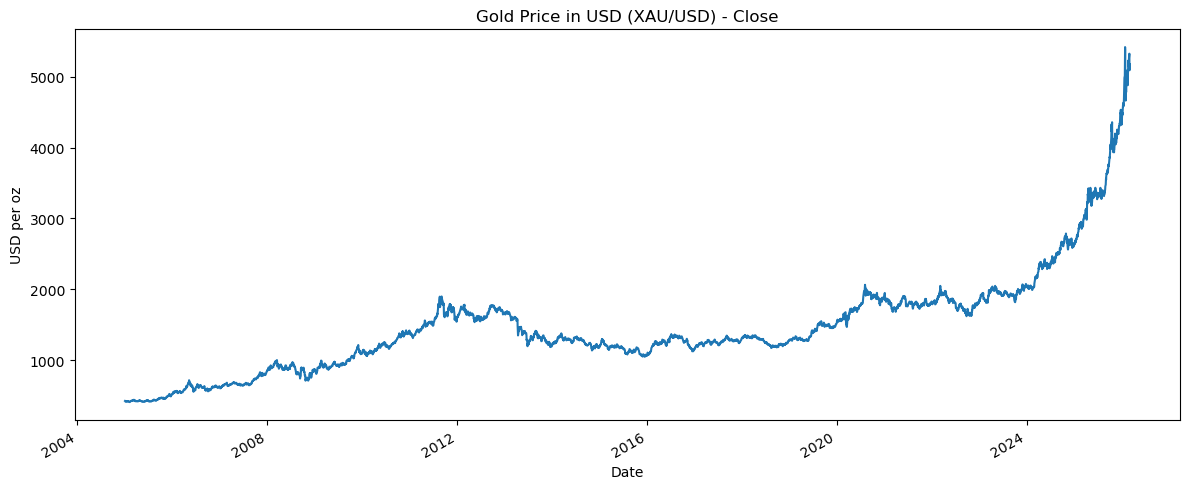

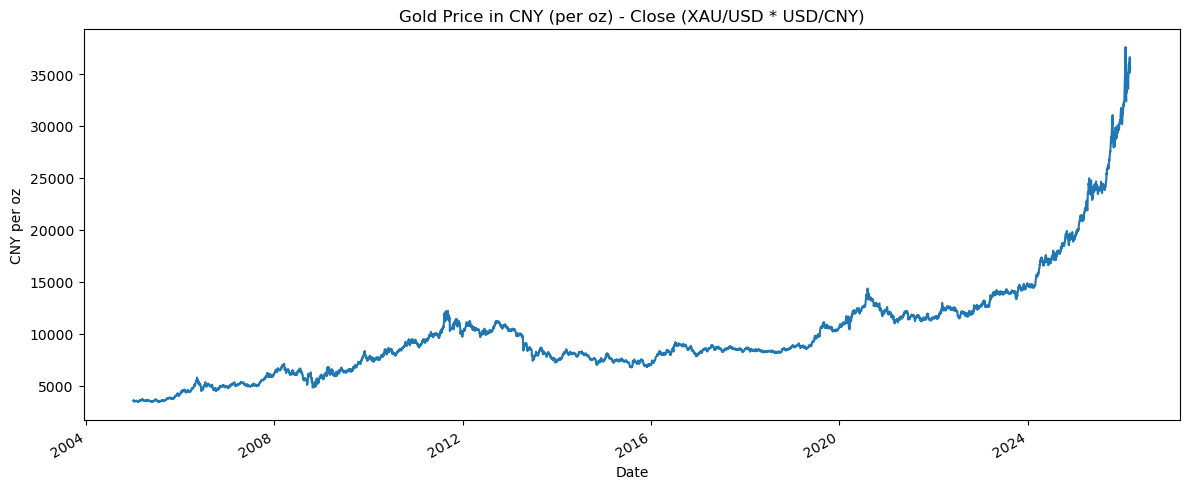

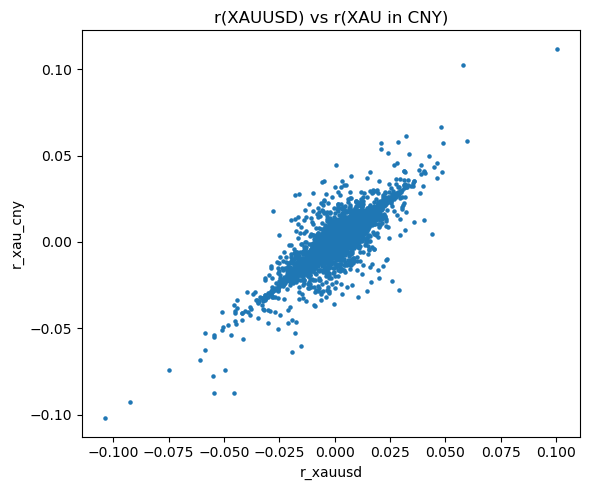

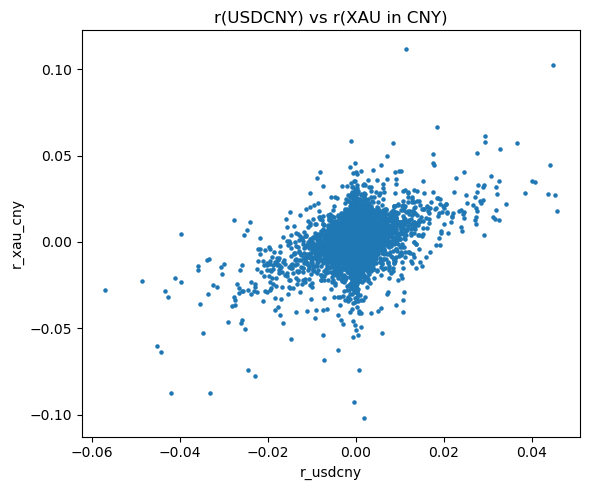

In [24]:
import os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# 1) USD price
plt.figure(figsize=(12,5))
df["XAUUSD"].plot()
plt.title("Gold Price in USD (XAU/USD) - Close")
plt.ylabel("USD per oz")
plt.tight_layout()
plt.savefig("figures/price_usd.png", dpi=200)
plt.show()

# 2) CNY price
plt.figure(figsize=(12,5))
df["XAU_CNY_per_oz"].plot()
plt.title("Gold Price in CNY (per oz) - Close (XAU/USD * USD/CNY)")
plt.ylabel("CNY per oz")
plt.tight_layout()
plt.savefig("figures/price_cny.png", dpi=200)
plt.show()

# 3) Scatter 1
plt.figure(figsize=(6,5))
plt.scatter(ret["r_xauusd"], ret["r_xau_cny"], s=5)
plt.title("r(XAUUSD) vs r(XAU in CNY)")
plt.xlabel("r_xauusd")
plt.ylabel("r_xau_cny")
plt.tight_layout()
plt.savefig("figures/scatter_xauusd_vs_cny.png", dpi=200)
plt.show()

# 4) Scatter 2
plt.figure(figsize=(6,5))
plt.scatter(ret["r_usdcny"], ret["r_xau_cny"], s=5)
plt.title("r(USDCNY) vs r(XAU in CNY)")
plt.xlabel("r_usdcny")
plt.ylabel("r_xau_cny")
plt.tight_layout()
plt.savefig("figures/scatter_usdcny_vs_cny.png", dpi=200)
plt.show()

In [26]:
import os
os.listdir("figures")

['scatter_xauusd_vs_cny.png',
 'price_usd.png',
 'price_cny.png',
 'scatter_usdcny_vs_cny.png']

In [28]:
import os
os.getcwd()

'/Users/niko/Desktop'